# BE Model Point Estimate Analysis

Essential validation of the Boundary Estimation (BE) model before moving to SBI inference.

---

## Purpose of This Notebook

This notebook performs **point estimate analysis** - fitting the model via MLE and checking basic behaviour. It answers:

1. **Does the model produce sensible behaviour?** (psychometric curves, accuracy)
2. **How does burn-in affect naive vs expert behaviour?**
3. **What do parameters do?** (single parameter sweeps on behaviour)
4. **How does heuristic contamination affect fitting?** (MixedAgent analysis)

### What We DON'T Need Here (Saved for SBI)

- **Joint parameter sweeps**: SBI posteriors show parameter interactions naturally
- **Sobol sensitivity analysis**: Posterior marginal widths encode the same information
- **Detailed recovery analysis**: SBI gives full uncertainty, not just point estimates

---

## Contents

### Part I: Foundations
1. [Setup and Imports](#1.-Setup-and-Imports)
2. [Basic Model Simulation](#2.-Basic-Model-Simulation)
3. [Psychometric Curve Analysis](#3.-Psychometric-Curve-Analysis)

### Part II: Burn-in Analysis
4. [Burn-in Effects on Behaviour](#4.-Burn-in-Effects-on-Behaviour)
5. [Burn-in Effects on Parameter Recovery](#5.-Burn-in-Effects-on-Parameter-Recovery)

### Part III: Parameter Effects on Behaviour
6. [Single Parameter Sweeps](#6.-Single-Parameter-Sweeps)

### Part IV: MixedAgent Analysis
7. [MixedAgent Simulation](#7.-MixedAgent-Simulation)
8. [BE Recovery from MixedAgent Data](#8.-BE-Recovery-from-MixedAgent-Data)

### Part V: Summary
9. [Key Findings and Limitations](#9.-Key-Findings-and-Limitations)

---

# Part I: Foundations

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Core utilities
from Helpers.utils import generate_stimuli, cumulative_gaussian
from Helpers.psychometry import fit_psychometric, compute_psychometric_gof

# Models - New stateless core
from Models.BE_core import BEParams, BEState, BEModel
from Models.BE_model import BoundaryEstimationModel
from Models.agent import MixedAgent

# Plotting
from Plotting.psychometric import plot_psychometric
from Plotting.recovery import (
    plot_burn_in_recovery,
    plot_burn_in_param_distributions,
    plot_be_param_behaviour_sweep,
    plot_behaviour_sweep_psychometrics_overlay,
    plot_mixed_agent_recovery,
    plot_mixed_agent_param_distributions,
)
from Plotting.session import plot_session

# Analysis functions
from Param_recovery.BE_agent_recovery import (
    burn_in_recovery_analysis,
    burn_in_recovery_summary_stats,
    plot_psychometric_by_burn_in,
    plot_belief_after_burn_in,
    be_param_behaviour_sweep,
    be_param_sweep_summary,
    mixed_agent_recovery_analysis,
    mixed_agent_recovery_summary_stats,
)

print("All imports successful!")

All imports successful!


In [2]:
# =============================================================================
# GLOBAL PARAMETERS
# =============================================================================

TRUE_BE_PARAMS = {
    'sigma_percep': 0.15,    # Perceptual noise
    'A_repulsion': 0.1,      # Serial dependence (repulsion)
    'eta_learning': 0.35,    # Learning rate (PRIMARY MEASURE for your research)
    'eta_relax': 0.12        # Relaxation rate toward uniform
}

HEURISTIC_PARAMS = {
    'bias': 0.05,            # Slight side bias
    'p_winstay': 0.6,        # Win-stay probability
    'p_loseshift': 0.4,      # Lose-shift probability
    'w_bias': 1.0,
    'w_winstay': 1.0,
    'w_loseshift': 1.0,
    'w_random': 0.5
}

# Analysis settings
N_TRIALS = 300
N_REPLICATES = 50  # Reduced from 100 - SBI will give proper uncertainty
SEED = 42

# Quick test settings (uncomment to speed up)
# N_TRIALS = 150
# N_REPLICATES = 10

print(f"True BE params: {TRUE_BE_PARAMS}")
print(f"Settings: n_trials={N_TRIALS}, n_replicates={N_REPLICATES}")

True BE params: {'sigma_percep': 0.15, 'A_repulsion': 0.1, 'eta_learning': 0.35, 'eta_relax': 0.12}
Settings: n_trials=300, n_replicates=50


## 2. Basic Model Simulation

Create a BE model, simulate a session, and visualise behaviour.

Accuracy: 81.0%
P(choose B): 0.51

Final belief mean: -0.2358
Final belief std: 0.4735


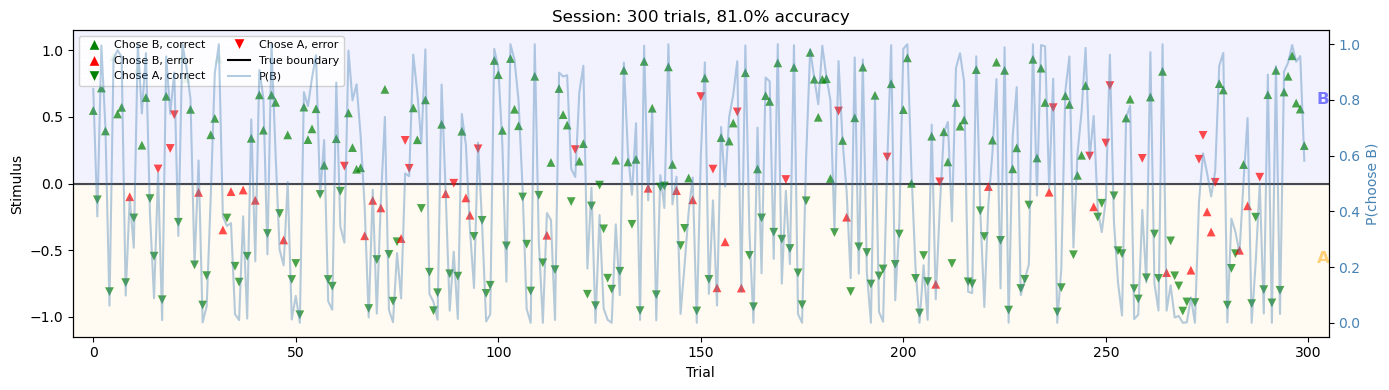

In [31]:
# Create model with expert-like burn-in
model = BoundaryEstimationModel(**TRUE_BE_PARAMS)
model.reset_belief(burn_in=1000, burn_in_seed=SEED)

# Generate stimuli and simulate
stimuli, categories, rng = generate_stimuli(n_trials=N_TRIALS, seed=SEED)
choices, p_B = model.simulate_session(stimuli, categories, rng=rng, store_history=True)

# Basic metrics
accuracy = np.mean(choices == categories)
print(f"Accuracy: {accuracy:.1%}")
print(f"P(choose B): {np.mean(choices):.2f}")

# Access underlying state (new functionality)
print(f"\nFinal belief mean: {model.state.belief_mean:.4f}")
print(f"Final belief std: {model.state.belief_std:.4f}")

fig = plot_session(stimuli, choices, categories, p_B)

# save as pdf
path = '/Users/Serkan/Desktop/pro/PhD/main/presentations/1on1/260129/Figures/BE_performance'
fig.savefig(path + '/BE_performance_session.pdf', format='pdf', bbox_inches='tight')

In [4]:
# Demonstrate the new stateless core directly
print("Using the new stateless core directly:")

params = BEParams(**TRUE_BE_PARAMS)
state = BEModel.create_initial_state(burn_in=1000, params=params, seed=SEED)

print(f"  BEParams: {params}")
print(f"  Initial state belief_std: {state.belief_std:.4f}")

# Simulate
rng = np.random.default_rng(SEED)
choices_core, p_B_core, final_state = BEModel.simulate_session(
    params, state, stimuli, categories, rng
)
print(f"  Accuracy: {np.mean(choices_core == categories):.1%}")

Using the new stateless core directly:
  BEParams: BEParams(sigma_percep=0.15, A_repulsion=0.1, eta_learning=0.35, eta_relax=0.12)
  Initial state belief_std: 0.4471
  Accuracy: 79.0%


## 3. Psychometric Curve Analysis

Fit and visualise the psychometric curve from simulated choices.

In [5]:
# Fit psychometric curve
psych = fit_psychometric(stimuli, choices, n_bootstrap=100)

print("Psychometric parameters:")
print(f"  μ (PSE):      {psych['mu']:.3f}")
print(f"  σ (slope):    {psych['sigma']:.3f}")
print(f"  lapse_low:    {psych['lapse_low']:.3f}")
print(f"  lapse_high:   {psych['lapse_high']:.3f}")

# Goodness of fit
gof = compute_psychometric_gof(stimuli, choices, psych)
print(f"\nGoodness of fit:")
print(f"  R²:                {gof['r_squared']:.3f}")
print(f"  Deviance explained: {gof['deviance_explained']:.3f}")

Psychometric parameters:
  μ (PSE):      -0.043
  σ (slope):    0.469
  lapse_low:    0.000
  lapse_high:   0.000

Goodness of fit:
  R²:                0.984
  Deviance explained: 0.420


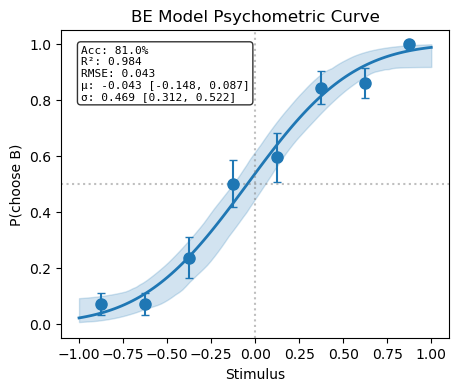

In [43]:
# Plot psychometric curve
fig, info = plot_psychometric(
    stimuli, choices,
    show_gof=True,
    show_params=True,
    n_bootstrap=100,
    title='BE Model Psychometric Curve'
)

path = '/Users/Serkan/Desktop/pro/PhD/main/presentations/1on1/260129/Figures/BE_performance'
fig.get_figure().savefig(path + '/BE_performance_psychometry.pdf', format='pdf', bbox_inches='tight')

---
# Part II: Burn-in Analysis

How does the model's experience level (burn-in) affect behaviour?

**Key for your research:**
- burn_in=0 → Naive animal (context learning phase, high η)
- burn_in=1000+ → Expert animal (inference phase, low η)

## 4. Burn-in Effects on Behaviour

Compare naive (burn_in=0) vs expert (burn_in=1000+) behaviour.

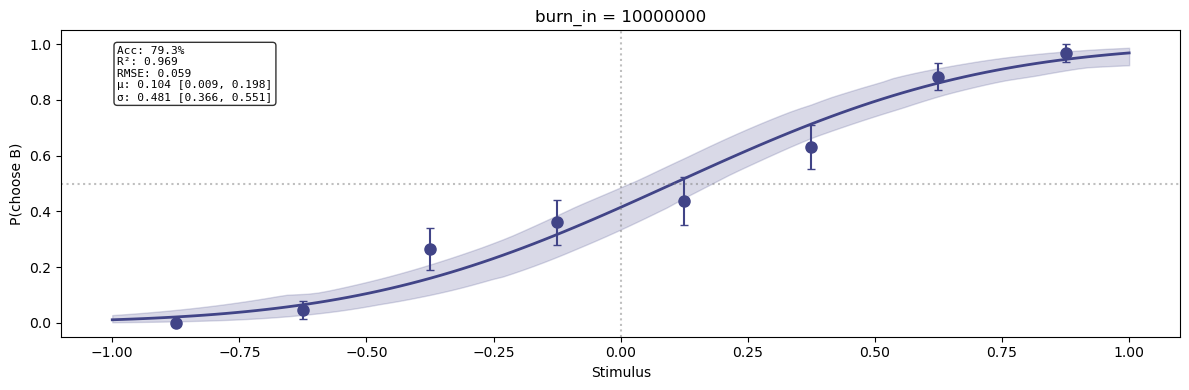


Metrics by burn-in:
 burn_in  accuracy    mu  sigma  r_squared
10000000     0.793 0.104  0.481      0.969


In [180]:
# Visualise psychometric curves at different burn-in levels
fig, gof_df = plot_psychometric_by_burn_in(
    params=TRUE_BE_PARAMS,
    burn_in_values=[
        # 0, 100, 500, 1000, 2000, 
        10000000],
    n_trials=N_TRIALS,
    show_gof=True,
    show_params=True,
    n_bootstrap=50
)
plt.show()

print("\nMetrics by burn-in:")
print(gof_df[['burn_in', 'accuracy', 'mu', 'sigma', 'r_squared']].round(3).to_string(index=False))
path = '/Users/Serkan/Desktop/pro/PhD/main/presentations/1on1/260129/Figures/BE_burn_in'
# fig.savefig(path + '/burnin_psychometry.pdf', format='pdf', bbox_inches='tight')

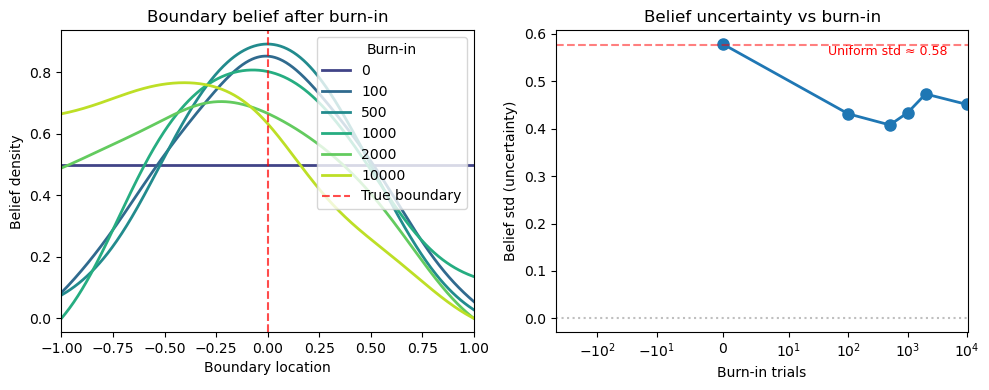

In [51]:
# Visualise belief distributions after different burn-in amounts
fig = plot_belief_after_burn_in(
    params=TRUE_BE_PARAMS,
    burn_in_values=[0, 100, 500, 1000, 2000, 10000]
)
plt.show()
fig.savefig(path + '/burnin_belief_distributions.pdf', format='pdf', bbox_inches='tight')

## 5. Burn-in Effects on Parameter Recovery

Does the fitter correctly recover parameters when there's a burn-in mismatch?

**Important insight:** If the fitter assumes wrong burn-in, it compensates by adjusting η_learning.

In [9]:
# Run burn-in recovery analysis
print("Running burn-in recovery analysis...")
results_burnin = burn_in_recovery_analysis(
    true_params=TRUE_BE_PARAMS,
    burn_in_values=[0, 500, 1000, 2000],
    n_trials=N_TRIALS,
    n_replicates=min(N_REPLICATES, 20),  # Fewer replicates needed
    fitter_burn_in=0,  # Fitter always assumes naive
    verbose=True
)

Running burn-in recovery analysis...

Testing burn_in = 0
  Replicate 1/20... OK
  Replicate 2/20... OK
  Replicate 3/20... OK
  Replicate 4/20... OK
  Replicate 5/20... OK
  Replicate 6/20... OK
  Replicate 7/20... OK
  Replicate 8/20... OK
  Replicate 9/20... OK
  Replicate 10/20... OK
  Replicate 11/20... OK
  Replicate 12/20... OK
  Replicate 13/20... OK
  Replicate 14/20... OK
  Replicate 15/20... OK
  Replicate 16/20... OK
  Replicate 17/20... OK
  Replicate 18/20... OK
  Replicate 19/20... OK
  Replicate 20/20... OK

Testing burn_in = 500
  Replicate 1/20... OK
  Replicate 2/20... OK
  Replicate 3/20... OK
  Replicate 4/20... OK
  Replicate 5/20... OK
  Replicate 6/20... OK
  Replicate 7/20... OK
  Replicate 8/20... OK
  Replicate 9/20... OK
  Replicate 10/20... OK
  Replicate 11/20... OK
  Replicate 12/20... OK
  Replicate 13/20... OK
  Replicate 14/20... OK
  Replicate 15/20... OK
  Replicate 16/20... OK
  Replicate 17/20... OK
  Replicate 18/20... OK
  Replicate 19/20... OK
 

In [10]:
# Summary statistics
df_burnin = burn_in_recovery_summary_stats(results_burnin)
print("\nBurn-in Recovery Summary:")
cols = ['burn_in', 'sigma_percep_bias', 'A_repulsion_bias', 
        'eta_learning_bias', 'eta_relax_bias']
available_cols = [c for c in cols if c in df_burnin.columns]
print(df_burnin[available_cols].round(4).to_string(index=False))


Burn-in Recovery Summary:
 burn_in  sigma_percep_bias  A_repulsion_bias  eta_learning_bias  eta_relax_bias
       0            -0.0566            0.0632             0.0810          0.0914
     500            -0.0522            0.0472             0.0515          0.0857
    1000            -0.0709            0.0611             0.0321          0.0685
    2000            -0.0675            0.0647             0.0770          0.0722


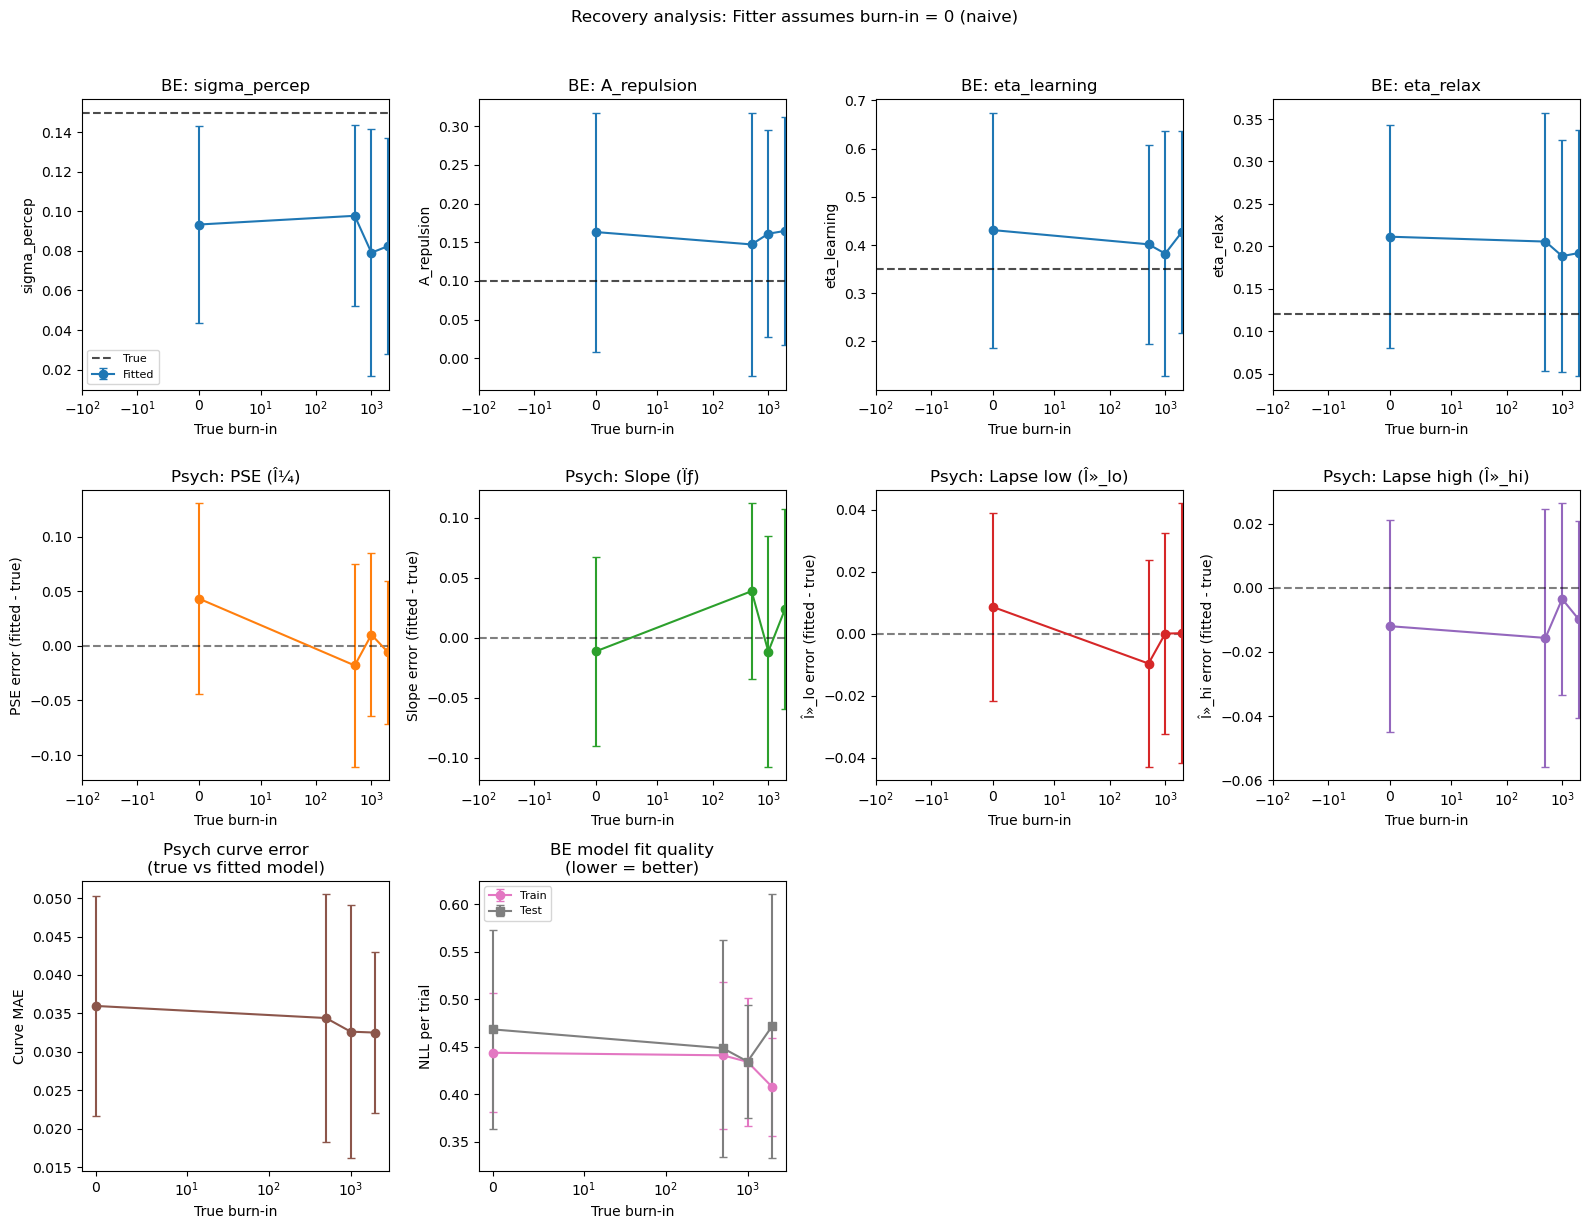

In [52]:
# Visualise recovery results
fig = plot_burn_in_recovery(results_burnin)
plt.tight_layout()
plt.show()
path = '/Users/Serkan/Desktop/pro/PhD/main/presentations/1on1/260129/Figures/BE_recovery'
fig.savefig(path + '/burnin_recovery.pdf', format='pdf', bbox_inches='tight')

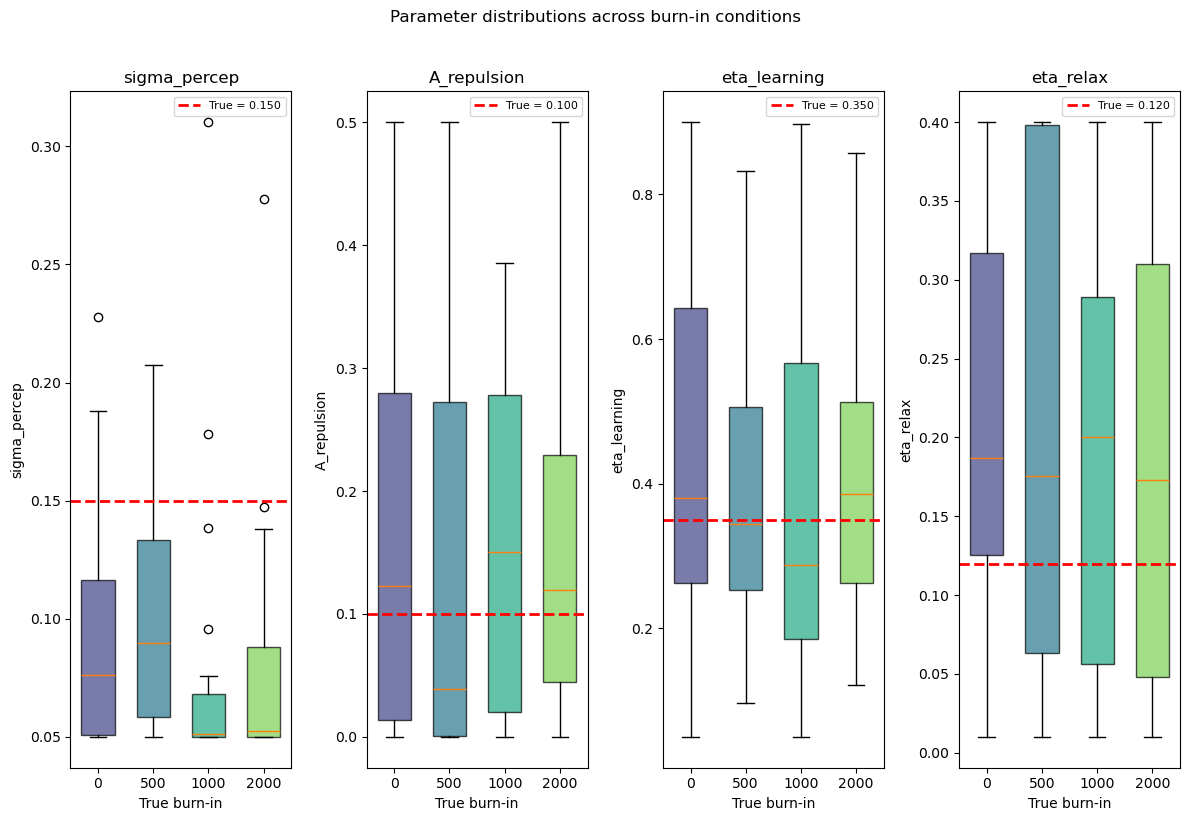

In [54]:
# Parameter distributions by burn-in
fig = plot_burn_in_param_distributions(results_burnin)
plt.tight_layout()
plt.show()
path = '/Users/Serkan/Desktop/pro/PhD/main/presentations/1on1/260129/Figures/BE_recovery'
fig.savefig(path + '/burnin_param_distributions.pdf', format='pdf', bbox_inches='tight')

In [13]:
# Key insight: eta_learning bias by burn-in
print("\nKey finding - η_learning bias by burn-in:")
print("(Positive bias = fitter overestimates learning rate)")
print("")
for burn_in in results_burnin['config']['burn_in_values']:
    try:
        bias = results_burnin['param_recovery'][burn_in]['eta_learning']['mean_error']
        print(f"  burn_in={burn_in:5d}: bias = {bias:+.4f}")
    except KeyError:
        print(f"  burn_in={burn_in:5d}: data not available")


Key finding - η_learning bias by burn-in:
(Positive bias = fitter overestimates learning rate)

  burn_in=    0: bias = +0.0810
  burn_in=  500: bias = +0.0515
  burn_in= 1000: bias = +0.0321
  burn_in= 2000: bias = +0.0770


---
# Part III: Parameter Effects on Behaviour

How do individual BE parameters affect behavioural outputs?

**Note:** We only do behaviour sweeps here, not recovery sweeps.
- Recovery sweep redundant: SBI posteriors will show parameter influence
- Joint sweeps redundant: SBI posteriors show parameter correlations
- Sobol analysis redundant: Posterior marginal widths encode sensitivity

## 6. Single Parameter Sweeps

Sweep one parameter while holding others fixed to see its effect on behaviour.

In [77]:
param = 'eta_learning' # or 'sigma_percep', 'A_repulsion', 'eta_relax', 'eta_learning
# Sweep for a BE Parameter
print(f"Sweeping {param}...")
results_sweep = be_param_behaviour_sweep(
    base_params=TRUE_BE_PARAMS,
    sweep_param=param,
    sweep_values=[0.05, 0.1, 0.2, 0.4, 0.8],
    burn_in_values=[0, 1000],
    n_trials=N_TRIALS,
    n_replicates=min(N_REPLICATES, 20),
    verbose=True
)

Sweeping eta_learning...

eta_learning = 0.05
  burn_in = 0... Acc=0.771±0.022, R²=0.968
  burn_in = 1000... Acc=0.767±0.023, R²=0.970

eta_learning = 0.1
  burn_in = 0... Acc=0.786±0.023, R²=0.966
  burn_in = 1000... Acc=0.792±0.024, R²=0.975

eta_learning = 0.2
  burn_in = 0... Acc=0.798±0.018, R²=0.972
  burn_in = 1000... Acc=0.814±0.020, R²=0.977

eta_learning = 0.4
  burn_in = 0... Acc=0.799±0.016, R²=0.978
  burn_in = 1000... Acc=0.800±0.017, R²=0.970

eta_learning = 0.8
  burn_in = 0... Acc=0.794±0.028, R²=0.976
  burn_in = 1000... Acc=0.799±0.025, R²=0.968


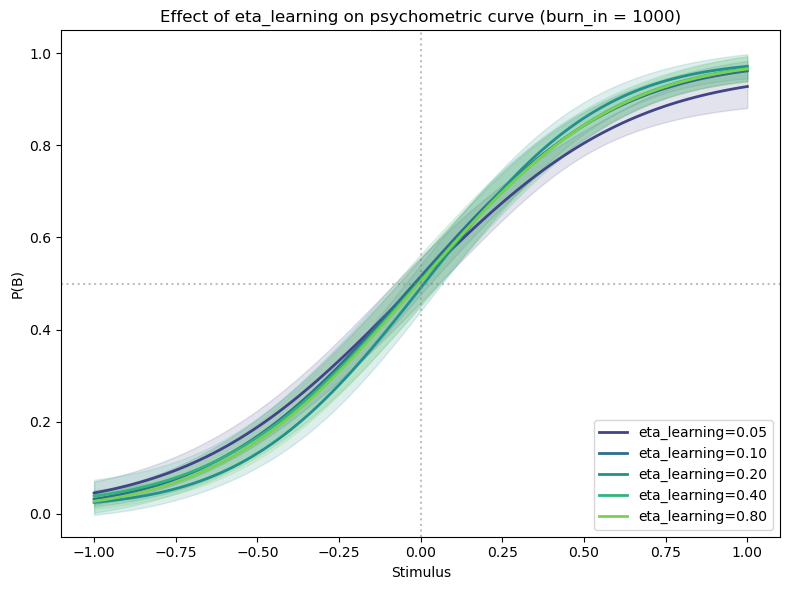

In [78]:
# Simpler: just show overlay for naive
n_burn_in = 1000
fig = plot_behaviour_sweep_psychometrics_overlay(results_sweep, burn_in=n_burn_in)
plt.title(f'Effect of {param} on psychometric curve (burn_in = {n_burn_in})')
plt.show()
path = '/Users/Serkan/Desktop/pro/PhD/main/presentations/1on1/260129/Figures/BE_sweep'
fig.savefig(path + f'/{param}_sweep_psychometrics_overlay.pdf', format='pdf', bbox_inches='tight')

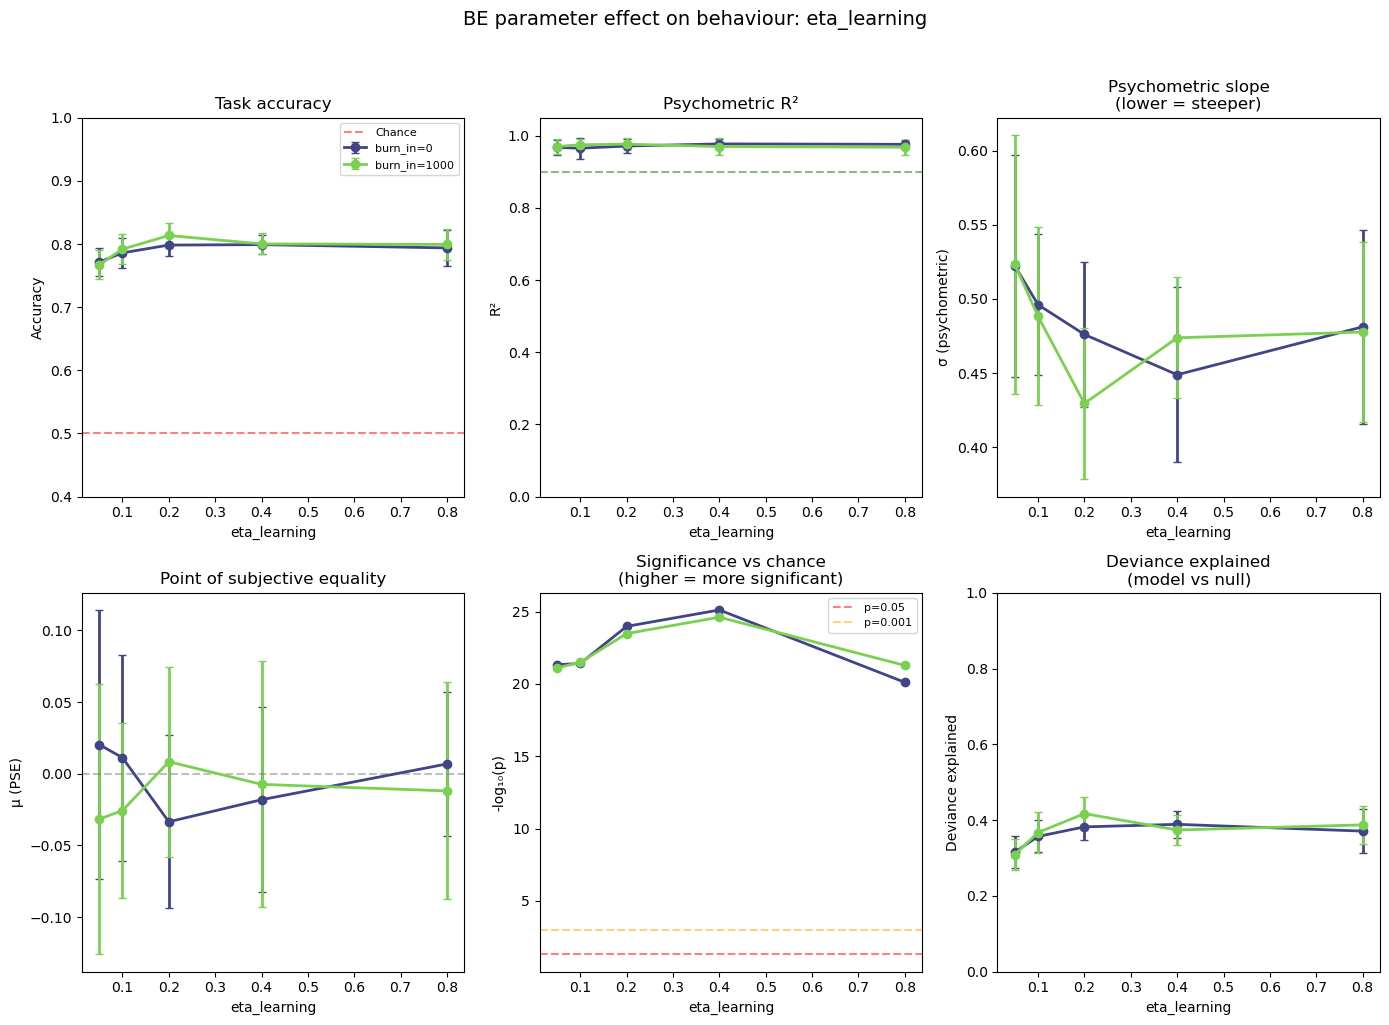

In [79]:
# Plot behaviour metrics
fig = plot_be_param_behaviour_sweep(results_sweep)
plt.tight_layout()
plt.show()
path = '/Users/Serkan/Desktop/pro/PhD/main/presentations/1on1/260129/Figures/BE_sweep'
fig.savefig(path + f'/{param}_sweep_behaviour_metrics.pdf', format='pdf', bbox_inches='tight')

In [80]:
# Summary table
df_param_sweep = be_param_sweep_summary(results_sweep, 'behaviour')
print(f"{param} effect on behaviour:")
print(df_param_sweep[[param, 'burn_in', 'accuracy_mean', 'r_squared_mean', 'sigma_mean']].round(3).to_string(index=False))

eta_learning effect on behaviour:
 eta_learning  burn_in  accuracy_mean  r_squared_mean  sigma_mean
         0.05        0          0.771           0.968       0.522
         0.05     1000          0.767           0.970       0.523
         0.10        0          0.786           0.966       0.496
         0.10     1000          0.792           0.975       0.488
         0.20        0          0.798           0.972       0.476
         0.20     1000          0.814           0.977       0.429
         0.40        0          0.799           0.978       0.449
         0.40     1000          0.800           0.970       0.474
         0.80        0          0.794           0.976       0.481
         0.80     1000          0.799           0.968       0.478


---
# Part IV: MixedAgent Analysis

The MixedAgent combines BE model with heuristic strategies:

$$P(B) = \alpha \times P(B|BE) + (1-\alpha) \times P(B|heuristics)$$

**Key question:** Can we detect when behaviour is BE-dominated vs heuristic-dominated?

## 7. MixedAgent Simulation

Simulate behaviour at different α levels.

In [136]:
HEURISTIC_PARAMS = {
    'bias': 0.4,            # Slight side bias
    'p_winstay': 0.8,        # Win-stay probability
    'p_loseshift': 0.8,      # Lose-shift probability
    'w_bias': 2.0,
    'w_winstay': 1.0,
    'w_loseshift': 1.0,
    'w_random': 0.5
}

In [137]:
# Simulate at different alpha levels
alpha_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

print("Simulating MixedAgent at different α levels...\n")

stimuli, categories, _ = generate_stimuli(n_trials=N_TRIALS, seed=SEED)

mixed_results = []
for alpha in alpha_values:
    agent = MixedAgent(
        **TRUE_BE_PARAMS,
        alpha=alpha,
        **HEURISTIC_PARAMS,
        burn_in=1000,
        burn_in_seed=SEED
    )
    
    choices, rewards = agent.simulate_session(stimuli, categories, rng=np.random.default_rng(SEED))
    
    accuracy = np.mean(rewards)
    psych = fit_psychometric(stimuli, choices)
    gof = compute_psychometric_gof(stimuli, choices, psych)
    
    mixed_results.append({
        'alpha': alpha,
        'accuracy': accuracy,
        'r_squared': gof['r_squared'],
        'sigma': psych['sigma'],
        'mu': psych['mu'],
        'lapse_low': psych['lapse_low'],
        'lapse_high': psych['lapse_high']
    })
    
    print(f"α={alpha:.1f}: Acc={accuracy:.2f}, R²={gof['r_squared']:.2f}, σ={psych['sigma']:.2f}")

df_mixed_sim = pd.DataFrame(mixed_results)

Simulating MixedAgent at different α levels...

α=0.0: Acc=0.46, R²=-0.97, σ=2.00
α=0.2: Acc=0.51, R²=0.12, σ=2.00
α=0.4: Acc=0.59, R²=0.81, σ=1.10
α=0.6: Acc=0.66, R²=0.93, σ=0.36
α=0.8: Acc=0.72, R²=0.97, σ=0.48
α=1.0: Acc=0.78, R²=0.97, σ=0.47


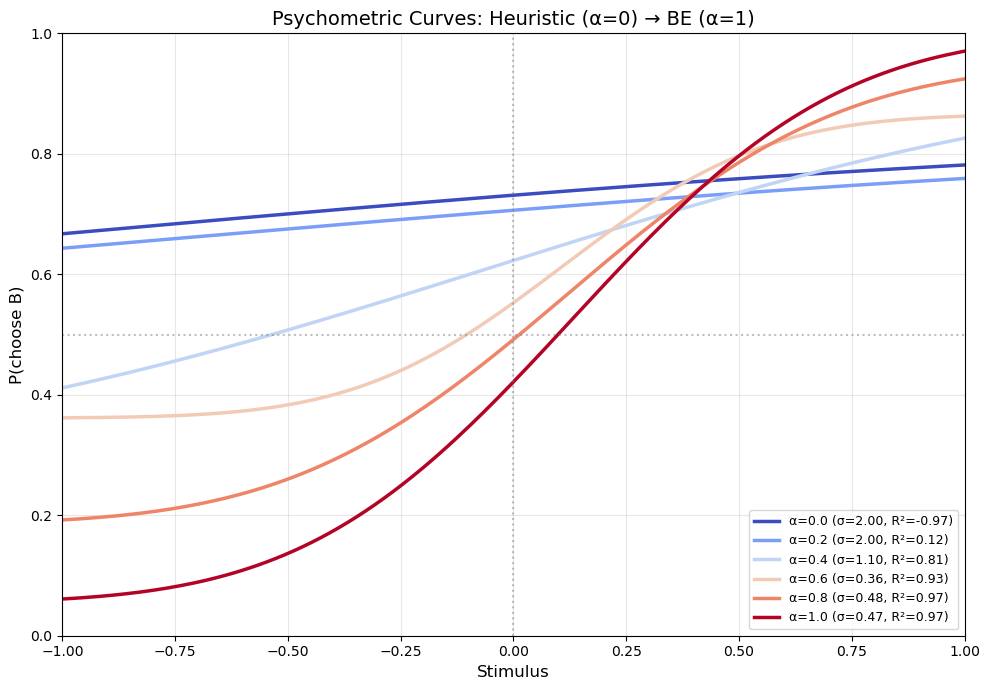

In [142]:
# Plot all psychometric curves using already-fitted params
fig, ax = plt.subplots(figsize=(10, 7))

colors = plt.cm.coolwarm(np.linspace(0, 1, len(alpha_values)))
x_plot = np.linspace(-1, 1, 200)

for i, row in df_mixed_sim.iterrows():
    y_plot = cumulative_gaussian(
        x_plot, 
        row['mu'], 
        row['sigma'], 
        row['lapse_low'], 
        row['lapse_high']
    )
    ax.plot(x_plot, y_plot, color=colors[i], linewidth=2.5,
            label=f"α={row['alpha']:.1f} (σ={row['sigma']:.2f}, R²={row['r_squared']:.2f})")

ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Stimulus', fontsize=12)
ax.set_ylabel('P(choose B)', fontsize=12)
ax.set_title('Psychometric Curves: Heuristic (α=0) → BE (α=1)', fontsize=14)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(-1, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

path = '/Users/Serkan/Desktop/pro/PhD/main/presentations/1on1/260129/Figures/MA_behaviour'
# fig.savefig(path + '/MA_behaviour_psychometrics.pdf', format='pdf', bbox_inches='tight')


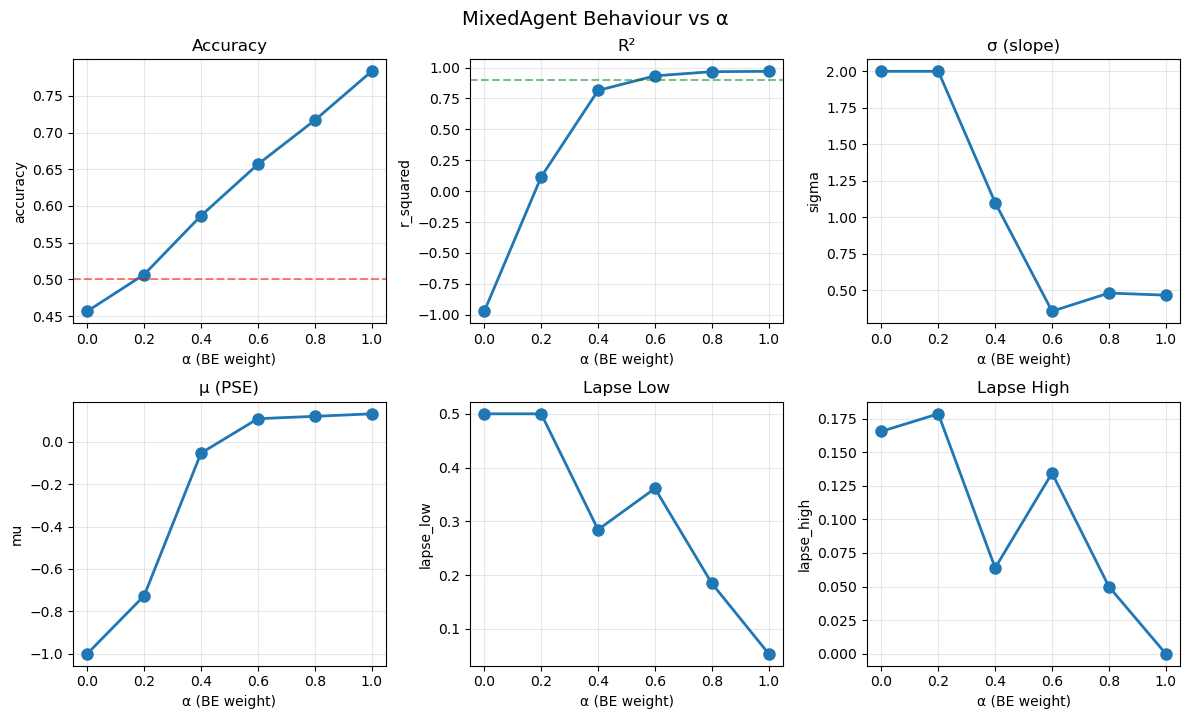

In [143]:
# Plot metrics vs alpha
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

metrics = ['accuracy', 'r_squared', 'sigma', 'mu', 'lapse_low', 'lapse_high']
titles = ['Accuracy', 'R²', 'σ (slope)', 'μ (PSE)', 'Lapse Low', 'Lapse High']

for ax, metric, title in zip(axes.flatten(), metrics, titles):
    ax.plot(df_mixed_sim['alpha'], df_mixed_sim[metric], 'o-', linewidth=2, markersize=8)
    ax.set_xlabel('α (BE weight)')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

# Add reference lines
axes[0, 0].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
axes[0, 1].axhline(0.9, color='green', linestyle='--', alpha=0.5, label='Good fit')

plt.tight_layout()
plt.suptitle('MixedAgent Behaviour vs α', y=1.02, fontsize=14)
plt.show()
path = '/Users/Serkan/Desktop/pro/PhD/main/presentations/1on1/260129/Figures/MA_behaviour'
# fig.savefig(path + '/MA_behaviour_metrics.pdf', format='pdf', bbox_inches='tight')

## 8. BE Recovery from MixedAgent Data

Can we recover the true BE parameters when behaviour is contaminated by heuristics?

In [144]:
# Run mixed agent recovery analysis
print("Running MixedAgent recovery analysis...")
results_mixed_rec_burn_in = mixed_agent_recovery_analysis(
    true_be_params=TRUE_BE_PARAMS,
    alpha_values=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    heuristic_params=HEURISTIC_PARAMS,
    n_trials=N_TRIALS,
    n_replicates=min(N_REPLICATES, 30),
    agent_burn_in=1000,
    fitter_burn_in=1000,
    verbose=True
)

Running MixedAgent recovery analysis...

Testing α = 0.00
  Replicate 1/30... OK
  Replicate 2/30... OK
  Replicate 3/30... OK
  Replicate 4/30... OK
  Replicate 5/30... OK
  Replicate 6/30... OK
  Replicate 7/30... OK
  Replicate 8/30... OK
  Replicate 9/30... OK
  Replicate 10/30... OK
  Replicate 11/30... OK
  Replicate 12/30... OK
  Replicate 13/30... OK
  Replicate 14/30... OK
  Replicate 15/30... OK
  Replicate 16/30... OK
  Replicate 17/30... OK
  Replicate 18/30... OK
  Replicate 19/30... OK
  Replicate 20/30... OK
  Replicate 21/30... OK
  Replicate 22/30... OK
  Replicate 23/30... OK
  Replicate 24/30... OK
  Replicate 25/30... OK
  Replicate 26/30... OK
  Replicate 27/30... OK
  Replicate 28/30... OK
  Replicate 29/30... OK
  Replicate 30/30... OK

Testing α = 0.20
  Replicate 1/30... OK
  Replicate 2/30... OK
  Replicate 3/30... OK
  Replicate 4/30... OK
  Replicate 5/30... OK
  Replicate 6/30... OK
  Replicate 7/30... OK
  Replicate 8/30... OK
  Replicate 9/30... OK
  Repl

In [147]:
# Summary
df_mixed_rec = mixed_agent_recovery_summary_stats(results_mixed_rec_burn_in)
print("\nMixedAgent Recovery Summary:")
cols = ['alpha', 'accuracy_mean', 'r_squared_mean', 
        'sigma_percep_bias', 'eta_learning_bias']
available_cols = [c for c in cols if c in df_mixed_rec.columns]
print(df_mixed_rec[available_cols].round(4).to_string(index=False))


MixedAgent Recovery Summary:
 alpha  accuracy_mean  r_squared_mean  sigma_percep_bias  eta_learning_bias
   0.0         0.4953         -0.2978            -0.0058            -0.0230
   0.2         0.5608          0.5344             0.0368             0.0547
   0.4         0.6273          0.8530             0.0057             0.0055
   0.6         0.6817          0.9355             0.0009            -0.0368
   0.8         0.7427          0.9587            -0.0315             0.0107
   1.0         0.8026          0.9729            -0.0517             0.0655


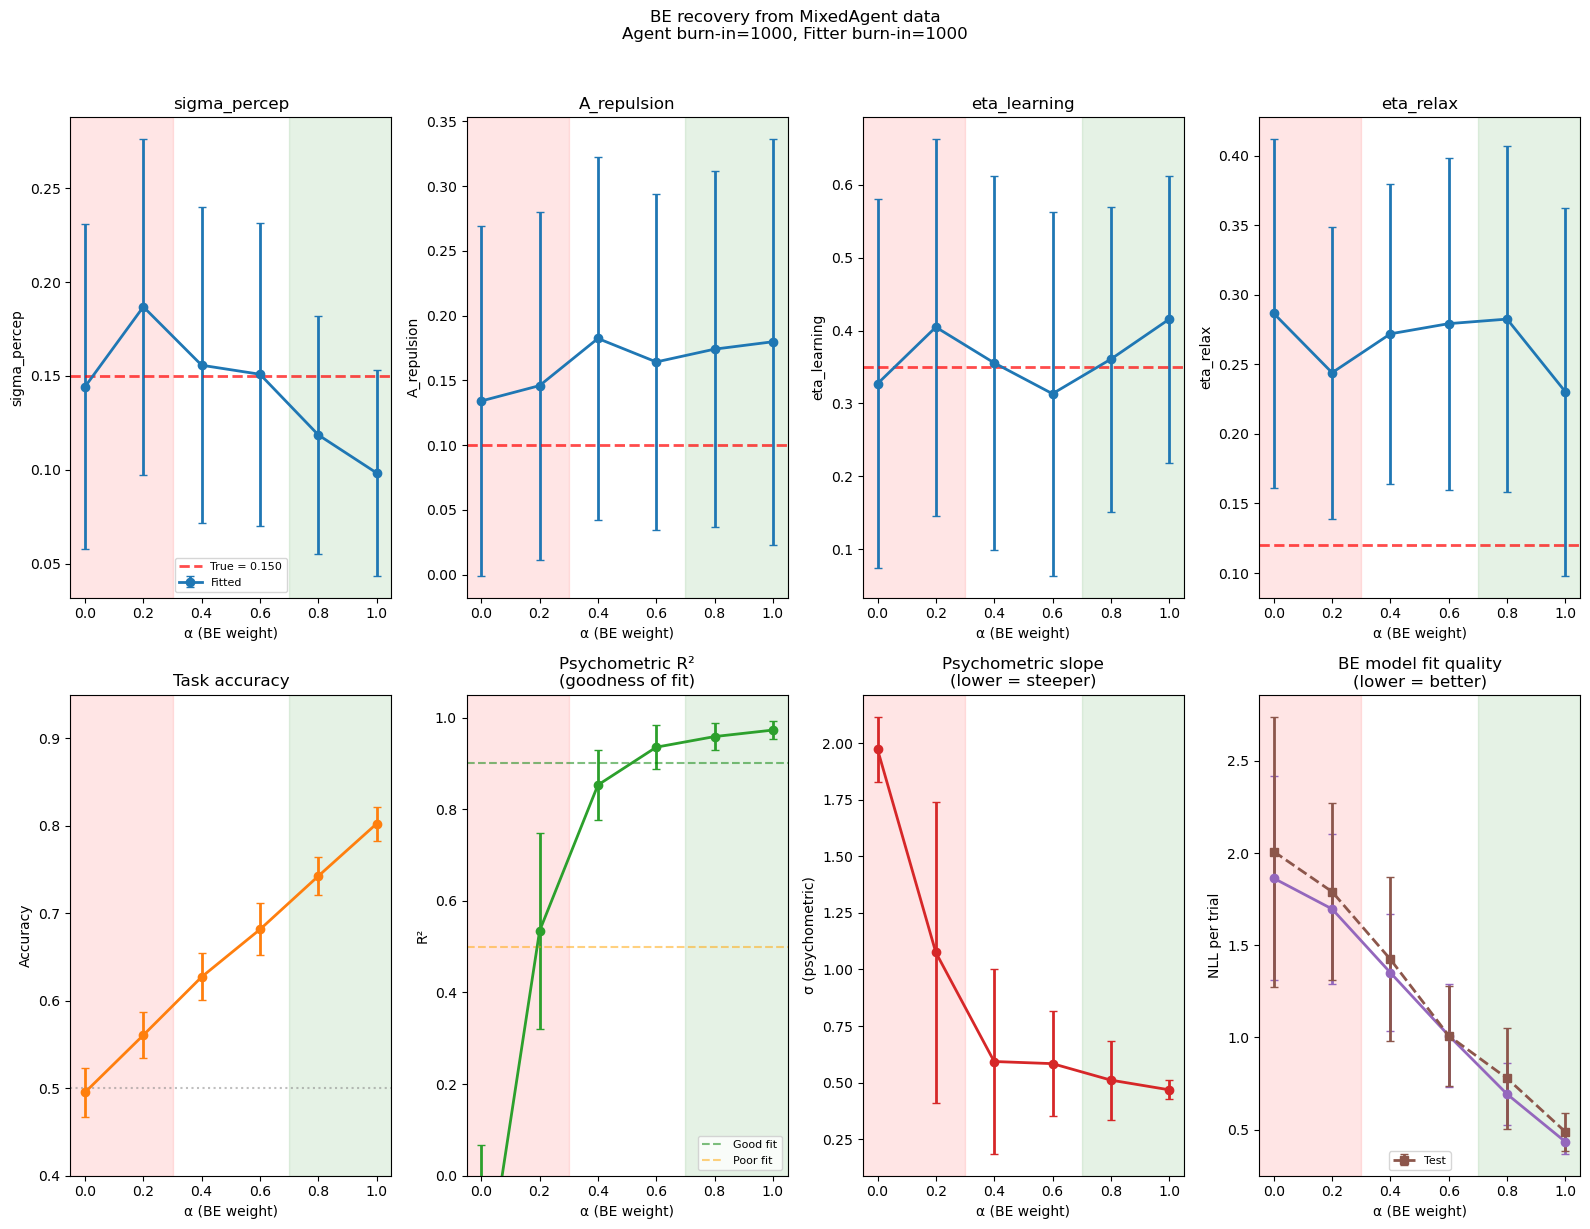

In [ ]:
# Recovery visualisation
fig = plot_mixed_agent_recovery(results_mixed_rec_burn_in)
plt.tight_layout()
plt.show()
path = '/Users/Serkan/Desktop/pro/PhD/main/presentations/1on1/260129/Figures/MA_behaviour'
# fig.savefig(path + '/MA_behaviour_recovery.pdf', format='pdf', bbox_inches='tight')

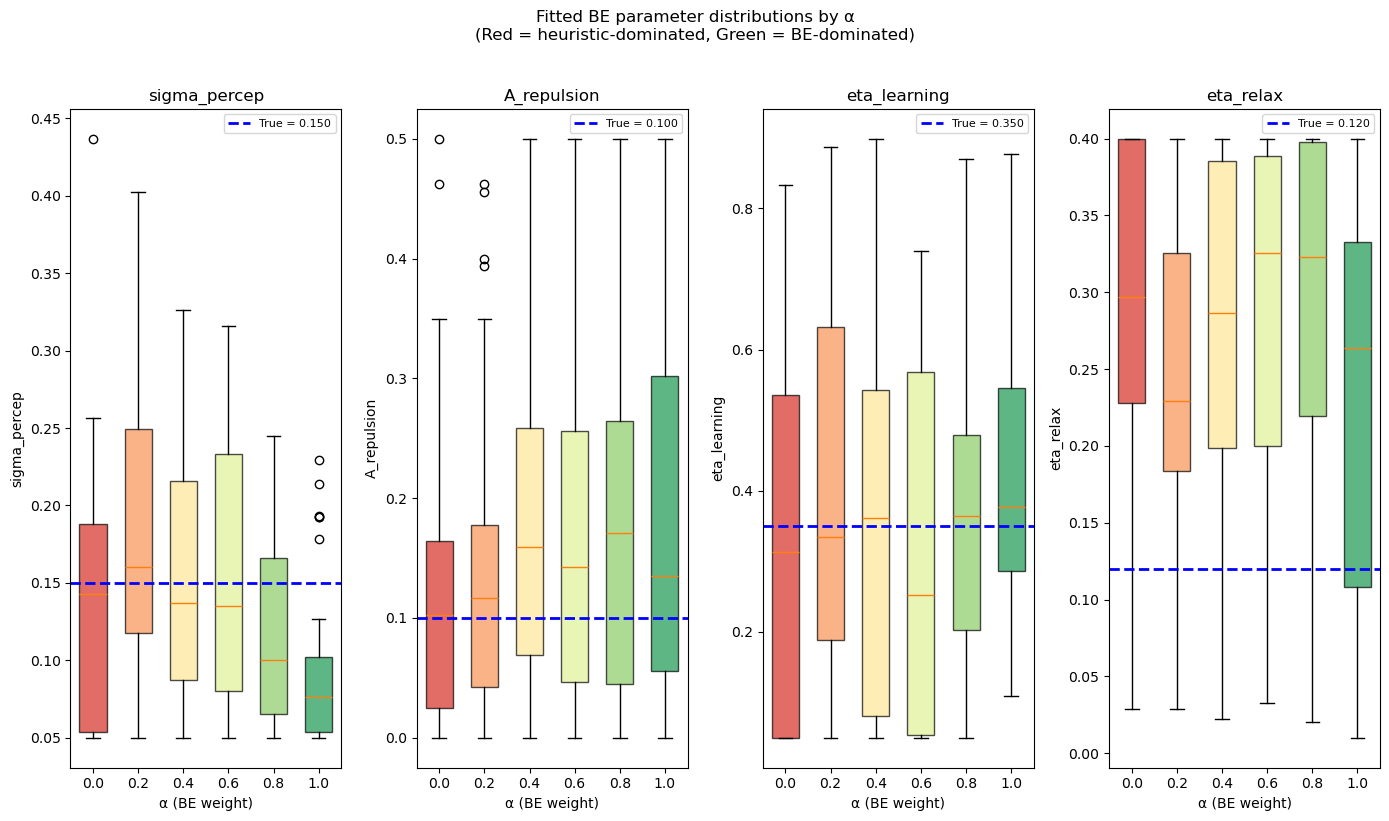

In [ ]:
# Parameter distributions
fig = plot_mixed_agent_param_distributions(results_mixed_rec_burn_in)
plt.tight_layout()
plt.show()
path = '/Users/Serkan/Desktop/pro/PhD/main/presentations/1on1/260129/Figures/MA_behaviour'
# fig.savefig(path + '/MA_behaviour_param_distributions.pdf', format='pdf', bbox_inches='tight')

In [149]:
# Run mixed agent recovery analysis
print("Running MixedAgent recovery analysis...")
results_mixed_rec = mixed_agent_recovery_analysis(
    true_be_params=TRUE_BE_PARAMS,
    alpha_values=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
    heuristic_params=HEURISTIC_PARAMS,
    n_trials=N_TRIALS,
    n_replicates=min(N_REPLICATES, 30),
    agent_burn_in=1000,
    fitter_burn_in=0,
    verbose=True
)

Running MixedAgent recovery analysis...

Testing α = 0.00
  Replicate 1/30... OK
  Replicate 2/30... OK
  Replicate 3/30... OK
  Replicate 4/30... OK
  Replicate 5/30... OK
  Replicate 6/30... OK
  Replicate 7/30... OK
  Replicate 8/30... OK
  Replicate 9/30... OK
  Replicate 10/30... OK
  Replicate 11/30... OK
  Replicate 12/30... OK
  Replicate 13/30... OK
  Replicate 14/30... OK
  Replicate 15/30... OK
  Replicate 16/30... OK
  Replicate 17/30... OK
  Replicate 18/30... OK
  Replicate 19/30... OK
  Replicate 20/30... OK
  Replicate 21/30... OK
  Replicate 22/30... OK
  Replicate 23/30... OK
  Replicate 24/30... OK
  Replicate 25/30... OK
  Replicate 26/30... OK
  Replicate 27/30... OK
  Replicate 28/30... OK
  Replicate 29/30... OK
  Replicate 30/30... OK

Testing α = 0.20
  Replicate 1/30... OK
  Replicate 2/30... OK
  Replicate 3/30... OK
  Replicate 4/30... OK
  Replicate 5/30... OK
  Replicate 6/30... OK
  Replicate 7/30... OK
  Replicate 8/30... OK
  Replicate 9/30... OK
  Repl

In [150]:
# Summary
df_mixed_rec = mixed_agent_recovery_summary_stats(results_mixed_rec)
print("\nMixedAgent Recovery Summary:")
cols = ['alpha', 'accuracy_mean', 'r_squared_mean', 
        'sigma_percep_bias', 'eta_learning_bias']
available_cols = [c for c in cols if c in df_mixed_rec.columns]
print(df_mixed_rec[available_cols].round(4).to_string(index=False))


MixedAgent Recovery Summary:
 alpha  accuracy_mean  r_squared_mean  sigma_percep_bias  eta_learning_bias
   0.0         0.4953         -0.2978             0.0031            -0.0309
   0.2         0.5608          0.5344             0.0279             0.0289
   0.4         0.6273          0.8530            -0.0000             0.0138
   0.6         0.6817          0.9355            -0.0022            -0.0300
   0.8         0.7427          0.9587            -0.0356             0.0415
   1.0         0.8026          0.9729            -0.0550             0.1079


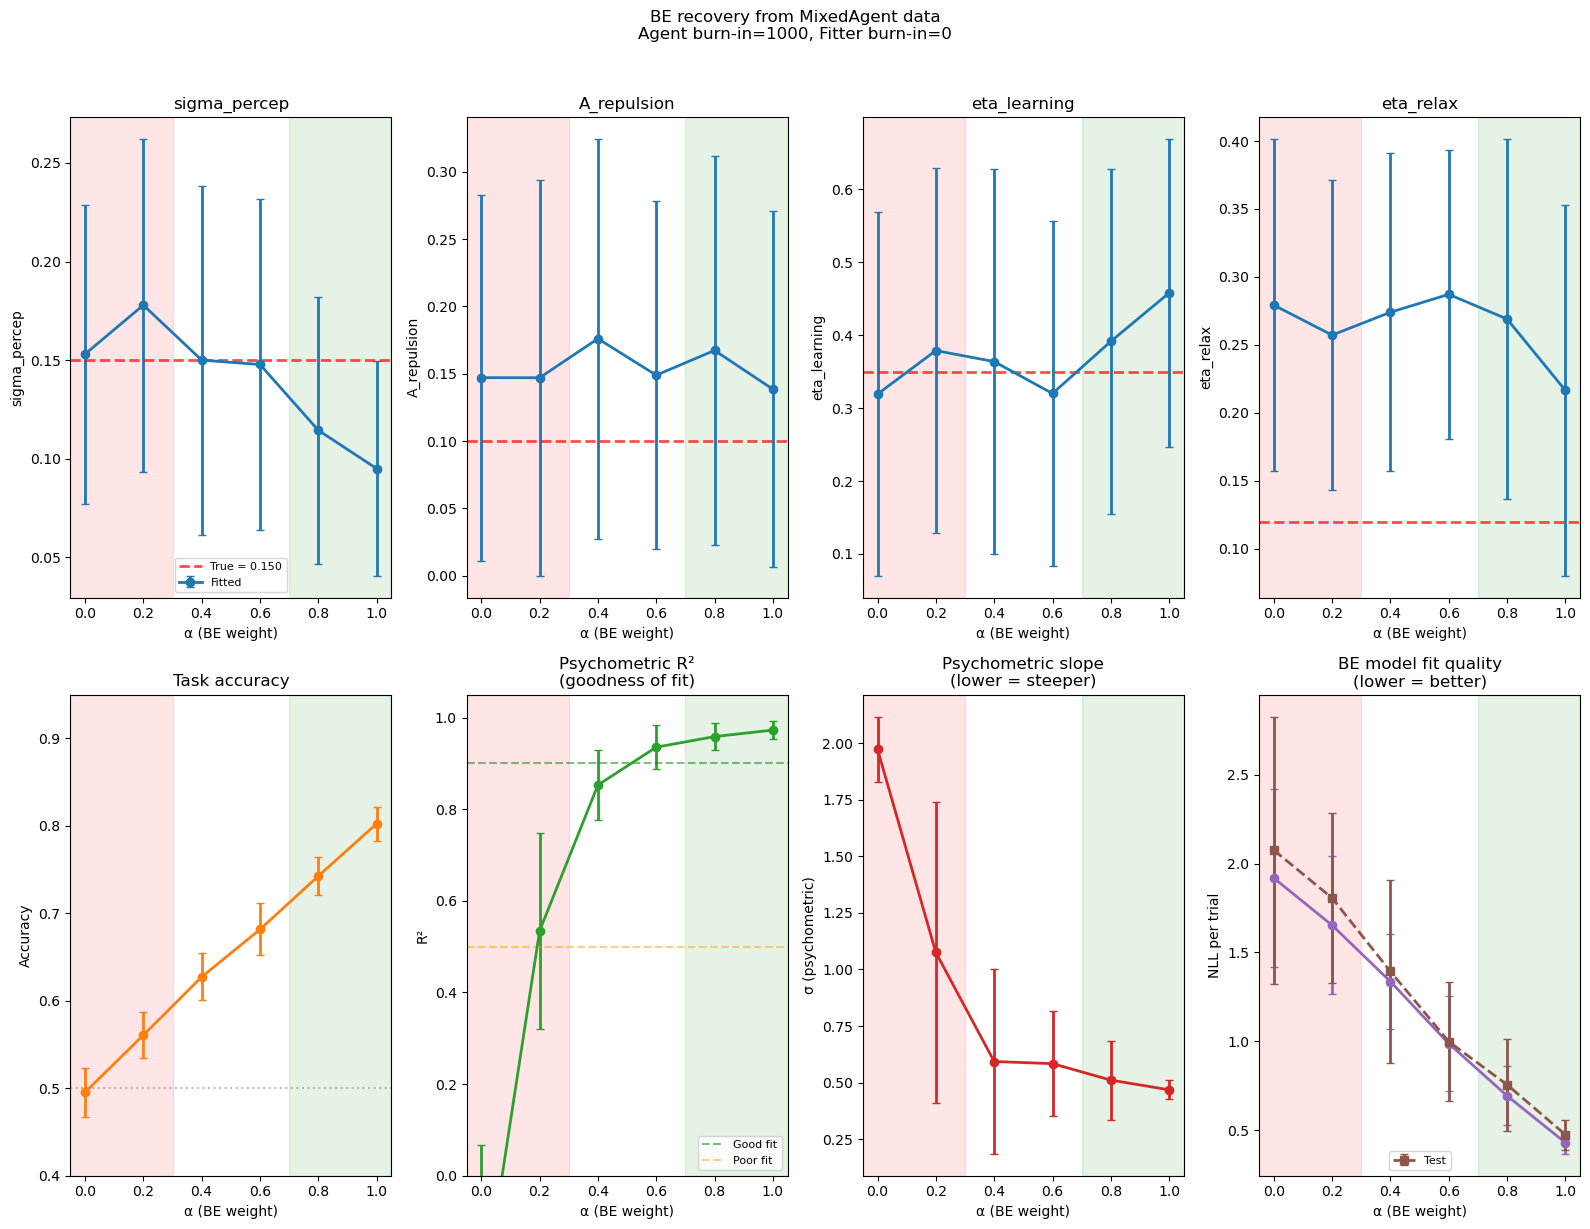

In [151]:
# Recovery visualisation
fig = plot_mixed_agent_recovery(results_mixed_rec)
plt.tight_layout()
plt.show()

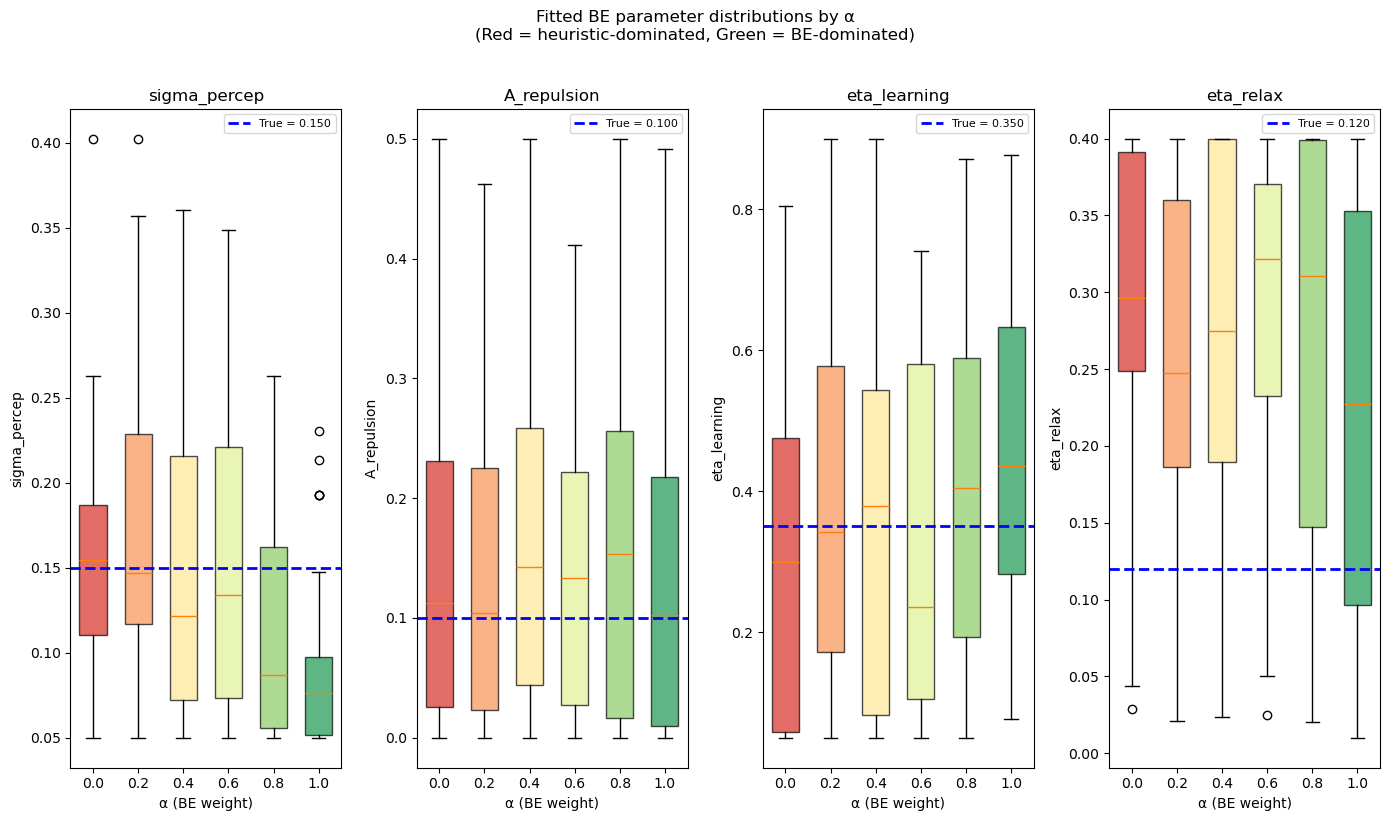

In [152]:
# Parameter distributions
fig = plot_mixed_agent_param_distributions(results_mixed_rec)
plt.tight_layout()
plt.show()

### Schema Detection Guide

What metrics best distinguish BE-dominated from heuristic-dominated behaviour?

In [29]:
print("""
SCHEMA DETECTION GUIDE
======================

Metric thresholds for detecting BE-dominated behaviour:

| Metric              | Heuristic-dominated | Transitional | BE-dominated |
|---------------------|--------------------:|-------------:|-------------:|
| R²                  |           < 0.5     |   0.5 - 0.85 |     > 0.85   |
| Accuracy            |           < 0.55    |  0.55 - 0.70 |     > 0.70   |
| Psychometric σ      |           > 1.0     |   0.5 - 1.0  |     < 0.5    |

α estimation from behaviour:
- α < 0.3:  Heuristic-dominated, unreliable parameter recovery
- α 0.3-0.7: Transitional, mixed behaviour
- α > 0.7:  BE-dominated, reasonable parameter recovery
""")


SCHEMA DETECTION GUIDE

Metric thresholds for detecting BE-dominated behaviour:

| Metric              | Heuristic-dominated | Transitional | BE-dominated |
|---------------------|--------------------:|-------------:|-------------:|
| R²                  |           < 0.5     |   0.5 - 0.85 |     > 0.85   |
| Accuracy            |           < 0.55    |  0.55 - 0.70 |     > 0.70   |
| Psychometric σ      |           > 1.0     |   0.5 - 1.0  |     < 0.5    |

α estimation from behaviour:
- α < 0.3:  Heuristic-dominated, unreliable parameter recovery
- α 0.3-0.7: Transitional, mixed behaviour
- α > 0.7:  BE-dominated, reasonable parameter recovery



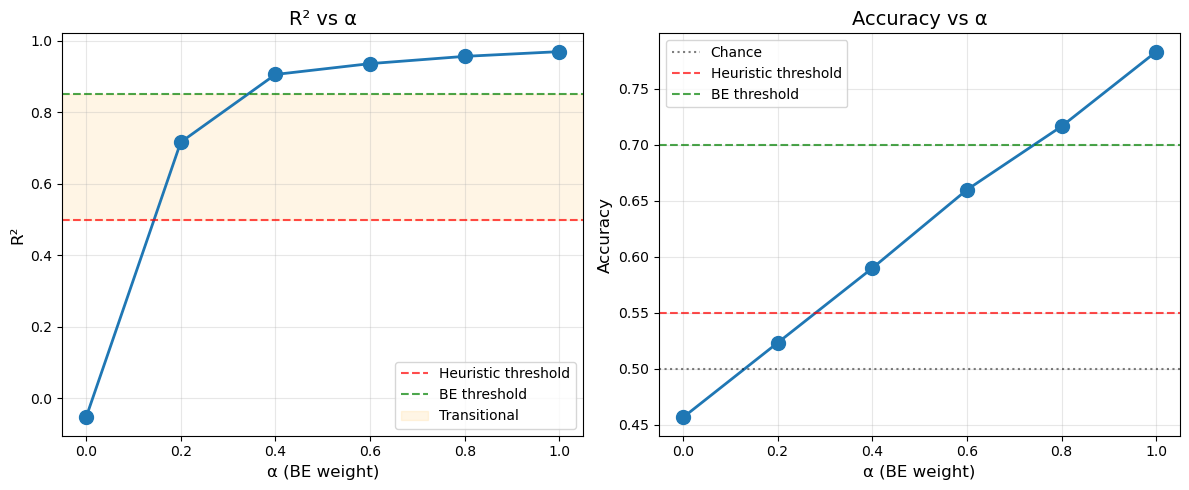

In [30]:
# Visualise thresholds
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R² vs alpha
ax = axes[0]
ax.plot(df_mixed_sim['alpha'], df_mixed_sim['r_squared'], 'o-', linewidth=2, markersize=10)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='Heuristic threshold')
ax.axhline(0.85, color='green', linestyle='--', alpha=0.7, label='BE threshold')
ax.axhspan(0.5, 0.85, alpha=0.1, color='orange', label='Transitional')
ax.set_xlabel('α (BE weight)', fontsize=12)
ax.set_ylabel('R²', fontsize=12)
ax.set_title('R² vs α', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy vs alpha
ax = axes[1]
ax.plot(df_mixed_sim['alpha'], df_mixed_sim['accuracy'], 'o-', linewidth=2, markersize=10)
ax.axhline(0.5, color='black', linestyle=':', alpha=0.5, label='Chance')
ax.axhline(0.55, color='red', linestyle='--', alpha=0.7, label='Heuristic threshold')
ax.axhline(0.70, color='green', linestyle='--', alpha=0.7, label='BE threshold')
ax.set_xlabel('α (BE weight)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy vs α', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Part V: Summary

## 9. Key Findings and Limitations

## Key Findings from Point Estimate Analysis

### 1. Parameter Effects on Behaviour
- **σ_percep** dominates accuracy — higher noise → worse performance
- **η_learning** affects adaptation speed and early-session psychometric slope
- **burn_in** sharpens initial belief but has modest effect on steady-state
- **A_repulsion** and **η_relax** have smaller effects on aggregate metrics

### 2. Burn-in Mismatch
- Fitting with wrong burn-in causes systematic biases, especially in η_learning
- Expert data (high burn-in) fitted with naive assumption → overestimated η_learning

### 3. Heuristic Contamination
- R² is the best single metric for detecting BE-dominated behaviour
- α > 0.7 needed for reliable parameter recovery
- Heuristic contamination causes systematic biases in all parameters

---

## Limitations of Point Estimate Analysis

| Limitation | Why It Matters | SBI Solution |
|------------|----------------|---------------|
| No uncertainty | Can't distinguish "well-determined" from "poorly-determined" | Full posterior distributions |
| Parameter trade-offs invisible | Multiple param combinations give same behaviour | Posterior correlations |
| Ridge-like likelihoods | MLE finds arbitrary point on ridge | Posterior shows full ridge |
| No formal model comparison | Can't test BE vs alternatives | Posterior predictive checks |

---

## What This Analysis Validated

✓ Model produces sensible behaviour (psychometric curves, accuracy ranges)  
✓ Parameters have expected directional effects  
✓ Burn-in correctly distinguishes naive vs expert  
✓ Heuristic detection is possible via goodness-of-fit metrics  
✓ New stateless core (`BEParams`, `BEState`, `BEModel`) works correctly  

---

## Ready for SBI

The model is validated and ready for Simulation-Based Inference, which will:
1. Give full posterior uncertainty on all parameters
2. Reveal parameter correlations and identifiability issues
3. Enable multi-session inference with GP priors on η_learning trajectory
4. Support formal model comparison

**Next notebook:** `BE_SBI_inference.ipynb`